## Analyse du data


In [1]:
# load data
import pandas as pd

df = pd.read_csv("../data/raw/jobs_data.csv")
df.head(10)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
5,5,Data Scientist,$137K-$171K (Glassdoor est.),About Us:\n\nHeadquartered in beautiful Santa ...,4.2,HG Insights\n4.2,"Santa Barbara, CA","Santa Barbara, CA",51 to 200 employees,2010,Company - Private,Computer Hardware & Software,Information Technology,Unknown / Non-Applicable,-1
6,6,Data Scientist / Machine Learning Expert,$137K-$171K (Glassdoor est.),Posting Title\nData Scientist / Machine Learni...,3.9,Novartis\n3.9,"Cambridge, MA","Basel, Switzerland",10000+ employees,1996,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$10+ billion (USD),-1
7,7,Data Scientist,$137K-$171K (Glassdoor est.),Introduction\n\nHave you always wanted to run ...,3.5,iRobot\n3.5,"Bedford, MA","Bedford, MA",1001 to 5000 employees,1990,Company - Public,Consumer Electronics & Appliances Stores,Retail,$1 to $2 billion (USD),-1
8,8,Staff Data Scientist - Analytics,$137K-$171K (Glassdoor est.),Intuit is seeking a Staff Data Scientist to co...,4.4,Intuit - Data\n4.4,"San Diego, CA","Mountain View, CA",5001 to 10000 employees,1983,Company - Public,Computer Hardware & Software,Information Technology,$2 to $5 billion (USD),"Square, PayPal, H&R Block"
9,9,Data Scientist,$137K-$171K (Glassdoor est.),Ready to write the best chapter of your career...,3.6,XSELL Technologies\n3.6,"Chicago, IL","Chicago, IL",51 to 200 employees,2014,Company - Private,Enterprise Software & Network Solutions,Information Technology,Unknown / Non-Applicable,-1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       672 non-null    str    
 8   Size               672 non-null    str    
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    str    
 11  Industry           672 non-null    str    
 12  Sector             672 non-null    str    
 13  Revenue            672 non-null    str    
 14  Competitors        672 non-null    str    
dtypes: float64(1), int64(2), str(12)
memory usage: 2.4 MB


In [3]:
df.describe()

,index,Rating,Founded
count,672.000000,672.000000,672.000000
mean,335.500000,3.518601,1635.529762
std,194.133974,1.410329,756.746640
min,0.000000,-1.000000,-1.000000
25%,167.750000,3.300000,1917.750000
50%,335.500000,3.800000,1995.000000
75%,503.250000,4.300000,2009.000000
max,671.000000,5.000000,2019.000000


In [4]:
df.columns.to_list()

['index',
 'Job Title',
 'Salary Estimate',
 'Job Description',
 'Rating',
 'Company Name',
 'Location',
 'Headquarters',
 'Size',
 'Founded',
 'Type of ownership',
 'Industry',
 'Sector',
 'Revenue',
 'Competitors']

In [5]:
df.shape

(672, 15)

In [6]:
# null values
print(df.isnull().sum())

index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64


In [7]:
# verifier les doublons
print("Doublons:", df.duplicated().sum())


Doublons: 0


In [8]:
# type 
print(df.dtypes)

index                  int64
Job Title                str
Salary Estimate          str
Job Description          str
Rating               float64
Company Name             str
Location                 str
Headquarters             str
Size                     str
Founded                int64
Type of ownership        str
Industry                 str
Sector                   str
Revenue                  str
Competitors              str
dtype: object


## Creation du salary_clean

In [9]:
df["Salary Estimate"].value_counts().head()

Salary Estimate
$75K-$131K (Glassdoor est.)     32
$79K-$131K (Glassdoor est.)     32
$99K-$132K (Glassdoor est.)     32
$137K-$171K (Glassdoor est.)    30
$90K-$109K (Glassdoor est.)     30
Name: count, dtype: int64

In [10]:
from preprocessing import clean_salary

df["salary_clean"] = df["Salary Estimate"].apply(clean_salary)

print(df[["Salary Estimate", "salary_clean"]].head())


                Salary Estimate  salary_clean
0  $137K-$171K (Glassdoor est.)      154000.0
1  $137K-$171K (Glassdoor est.)      154000.0
2  $137K-$171K (Glassdoor est.)      154000.0
3  $137K-$171K (Glassdoor est.)      154000.0
4  $137K-$171K (Glassdoor est.)      154000.0


In [11]:
print("Null values:", df["salary_clean"].isnull().sum())


Null values: 0


In [12]:
print(df["salary_clean"].describe())


count       672.000000
mean     123663.690476
std       39580.267895
min       43500.000000
25%      103000.000000
50%      114000.000000
75%      136500.000000
max      271500.000000
Name: salary_clean, dtype: float64


## Visualisation

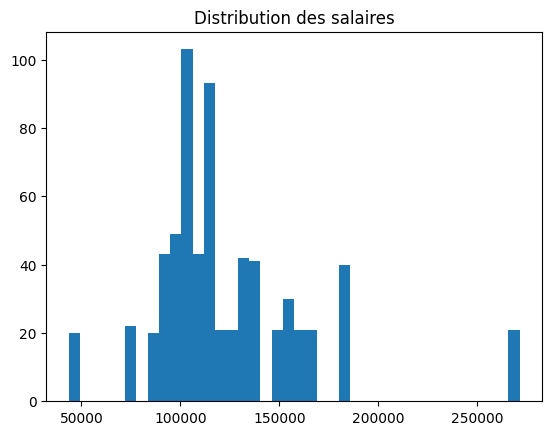

In [13]:
import matplotlib.pyplot as plt

plt.hist(df["salary_clean"].dropna(), bins=40)
plt.title("Distribution des salaires")
plt.show()


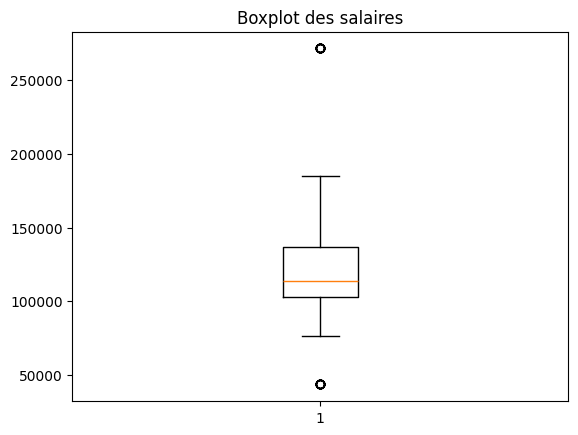

In [14]:
# verrification les outliers
plt.boxplot(df["salary_clean"].dropna())
plt.title("Boxplot des salaires")
plt.show()


In [15]:
# supprimer outliers
df = df[(df["salary_clean"] >= 5000) &
        (df["salary_clean"] <= 200000)
]

## Nettoyage des features

In [16]:
# supprimer la note (Rating) qui est collee au nom de l'entreprise

df['company_name'] = df['Company Name'].apply(lambda x: x.split('\n')[0])

df[['Company Name', 'company_name']].head()

,Company Name,company_name
0,Healthfirst\n3.1,Healthfirst
1,ManTech\n4.2,ManTech
2,Analysis Group\n3.8,Analysis Group
3,INFICON\n3.5,INFICON
4,Affinity Solutions\n2.9,Affinity Solutions


In [17]:
# extraction de location

df['location'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())

print(df['location'].value_counts().head())

location
CA    164
VA     87
MA     60
NY     49
MD     39
Name: count, dtype: int64


In [18]:
# calcule de l'age de l'entreprise

df['founded'] = df.Founded.apply(lambda x: x if x < 1 else 2024 - x)
df[['Founded', 'founded']].head()

,Founded,founded
0,1993,31
1,1968,56
2,1981,43
3,2000,24
4,1998,26


In [19]:
# 

from preprocessing import job_title, extract_seniority, extract_role

df["job_title"] = df["Job Title"].apply(job_title)

df["Seniority"] = df["job_title"].apply(extract_seniority)
df["role"] = df["job_title"].apply(extract_role)

df[['Job Title', 'role']].head()


,Job Title,role
0,Sr Data Scientist,Data Scientist
1,Data Scientist,Data Scientist
2,Data Scientist,Data Scientist
3,Data Scientist,Data Scientist
4,Data Scientist,Data Scientist


## Embeddings

In [21]:
# embeddings du Job Description

from embedding import load_embedding_model, generate_embedding

model = load_embedding_model()

job_description = df["Job Description"].tolist()
embeddings = generate_embedding(model, job_description)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 548.44it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Normalize

In [22]:
from embedding import normalize_embeddings

embedding_norm = normalize_embeddings(embeddings)

## Stocker dans chromadb


In [ ]:
from embedding import save_chroma

chromadb = save_chroma(df, embedding_norm)

In [ ]:
#  sauvgarder clean data

df_cleaned = df[['role',
 'salary_clean',
 'Job Description',
 'Rating',
 'company_name',
 'location',
 'Headquarters',
 'Size',
 'founded',
 'Type of ownership',
 'Industry',
 'Sector',
 'Revenue',
 'Competitors']]

# Sauvegarder le fichier propre
df_cleaned.to_csv('../data/processed/jobs_data_cleaned.csv', index=False)


Fichier nettoyé sauvegardé sous 'jobs_data_cleaned.csv' !


,role,salary_clean,Job Description,Rating,company_name,location,Headquarters,Size,founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Data Scientist,154000.0,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,NY,"New York, NY",1001 to 5000 employees,31,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,154000.0,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,VA,"Herndon, VA",5001 to 10000 employees,56,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,Data Scientist,154000.0,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,MA,"Boston, MA",1001 to 5000 employees,43,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,154000.0,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,MA,"Bad Ragaz, Switzerland",501 to 1000 employees,24,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,154000.0,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,NY,"New York, NY",51 to 200 employees,26,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
